Decision Tree Classification Results
--------------------------------------------------
Target variable: PRESS_CLASS (derived from PRESS_MEAN tertiles)
Independent variables: ['press_min', 'press_max', 'press_range', 'sol_lon', 'martian_day', 'viking_year']
Low <= 7.762, Medium <= 8.412, High > 8.412
Accuracy: 0.9909
Tree depth: 6
Number of leaves: 16

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       220
         Low       0.99      0.99      0.99       223
      Medium       0.99      0.99      0.99       217

    accuracy                           0.99       660
   macro avg       0.99      0.99      0.99       660
weighted avg       0.99      0.99      0.99       660



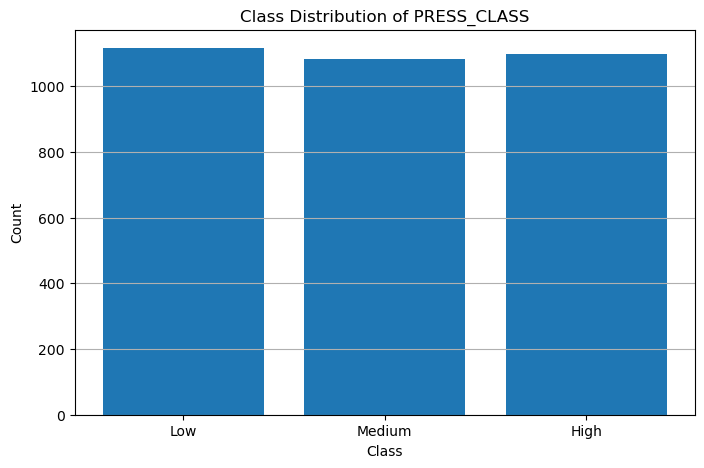

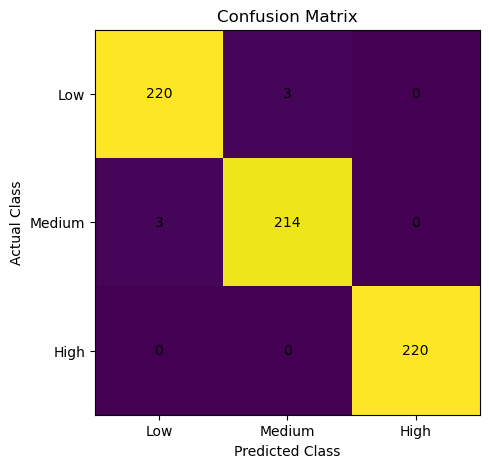

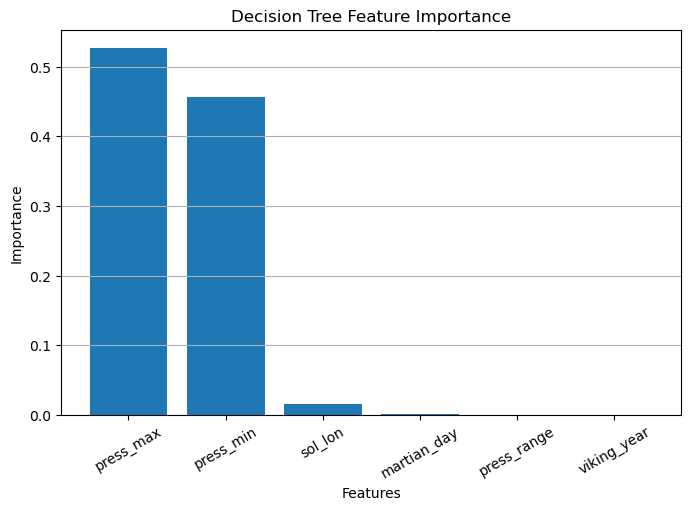

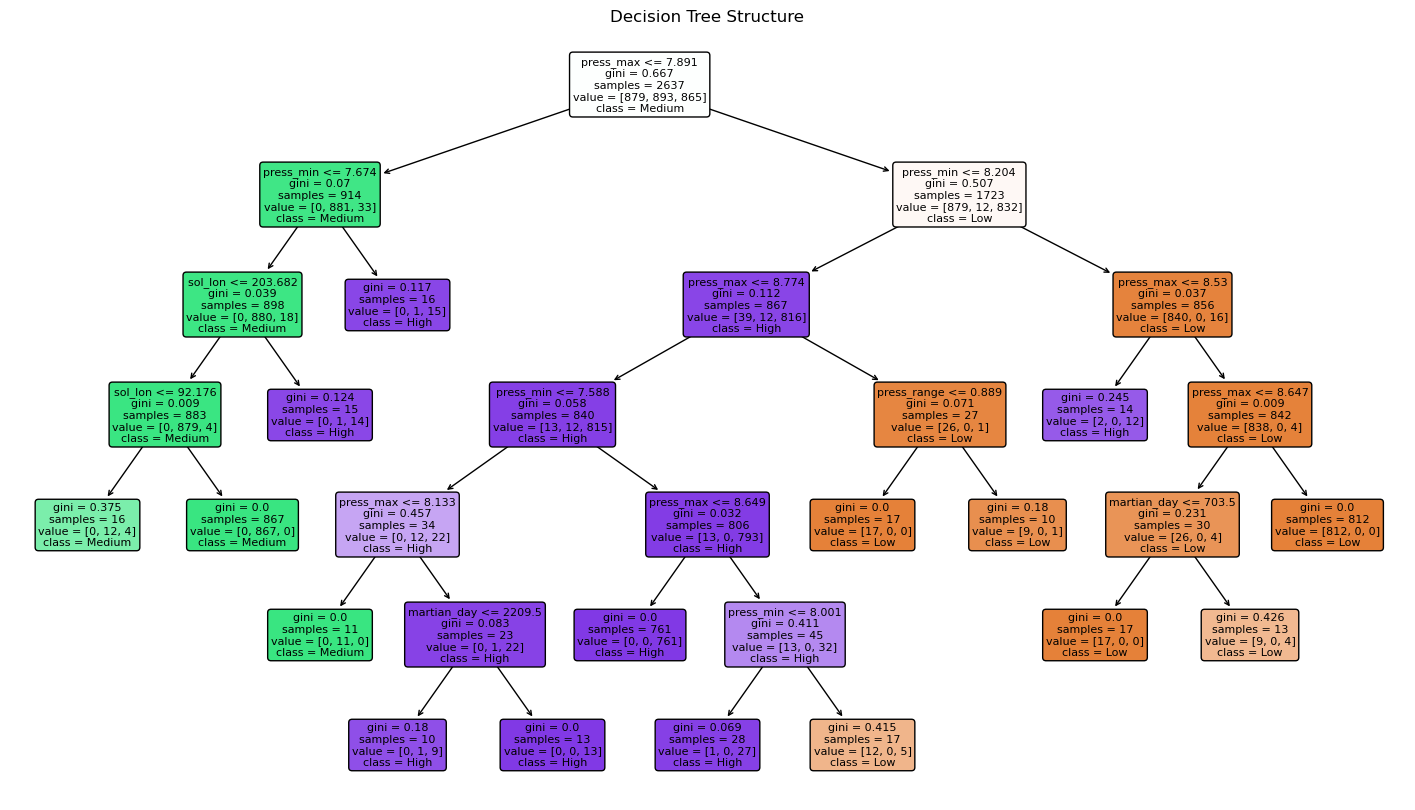

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("C:/Users/prabh/Documents/Mars_Dataset/Mars_DataSet_v1.csv")

# Clean columns
df.columns = df.columns.str.strip().str.lower()
df = df.replace(-9.999, np.nan)
df["date"] = pd.to_datetime(df["date"], format="%d-%b-%y", errors="coerce")

# Create target classes from PRESS_MEAN tertiles
q1, q2 = df["press_mean"].quantile([1/3, 2/3])

df["press_class"] = pd.cut(
    df["press_mean"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Medium", "High"]
)

# Feature selection
features = ["press_min", "press_max", "press_range", "sol_lon", "martian_day", "viking_year"]

# Final modeling data
model_df = df[features + ["press_class"]].dropna().copy()

X = model_df[features]
y = model_df["press_class"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Decision Tree model
tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

# Predictions
y_pred = tree_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])
report = classification_report(y_test, y_pred)

print("Decision Tree Classification Results")
print("-" * 50)
print("Target variable: PRESS_CLASS (derived from PRESS_MEAN tertiles)")
print("Independent variables:", features)
print(f"Low <= {q1:.3f}, Medium <= {q2:.3f}, High > {q2:.3f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Tree depth: {tree_model.get_depth()}")
print(f"Number of leaves: {tree_model.get_n_leaves()}")
print("\nClassification Report:\n")
print(report)

# 1. Class distribution
class_counts = y.value_counts().reindex(["Low", "Medium", "High"])
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution of PRESS_CLASS")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(True, axis="y")
plt.show()

# 2. Confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks([0, 1, 2], ["Low", "Medium", "High"])
plt.yticks([0, 1, 2], ["Low", "Medium", "High"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.show()

# 3. Feature importance
importances = pd.Series(tree_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
plt.bar(importances.index, importances.values)
plt.title("Decision Tree Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=30)
plt.grid(True, axis="y")
plt.show()

# 4. Decision tree structure
plt.figure(figsize=(18, 10))
plot_tree(
    tree_model,
    feature_names=features,
    class_names=["Low", "Medium", "High"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Structure")
plt.show()